In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## 005: Which density model works best on our video?

Goal. In E004 we proved our CSRNet code works, but ShanghaiTech Part B averages 124 people per image, and our video has about 454 per frame. Here we run three models on our own video and score them against the 15 frames we labelled by hand:

Official Part A weights (trained on dense scenes, about 500 people per image)
Official Part B weights (sparser scenes)
Our own Adam-trained model from E004

What we produce. A density map and a count for every one of the 1,303 frames, saved for the pressure work later, plus a table of how far each model's count is from our labels.

How we decide. The model with the lowest error on the labelled frames, checking its bias too. If all three undercount badly, we record by how much, because that decides the correction we build next (the injection test).

Care needed. 15 frames is a small sample. We report error per frame as well as the average, and we don't tune anything on the same 15 frames we score on.

## Cell 2: Load the project and find our files

This cell downloads the project code, checks the GPU, then scans everything attached to the notebook and lists the video, the three sets of weights, the registration file and any label files. It chooses each one automatically and stops with a clear message if something is missing or ambiguous, so we never run on the wrong file.

In [1]:
import os, subprocess, time
from pathlib import Path
import numpy as np, pandas as pd, cv2

REPO_URL = "https://github.com/SagarInspires/crowd-intelligence.git"
REPO_DIR = Path("/kaggle/working/crowd-intelligence")
OUT7 = Path("/kaggle/working/outputs/E005")
INPUT = Path("/kaggle/input")
OUT7.mkdir(parents=True, exist_ok=True)

def sync_repo(url, dest):
    """Purpose: clone the project repo, or pull if it is already there, and print the commit."""
    if (dest / ".git").exists():
        subprocess.run(["git", "-C", str(dest), "pull", "--ff-only", "-q"], check=False)
    else:
        subprocess.run(["git", "clone", "-q", url, str(dest)], check=True)
    sha = subprocess.run(["git", "-C", str(dest), "rev-parse", "--short", "HEAD"],
                         capture_output=True, text=True).stdout.strip()
    print(f"repo at {dest} (commit {sha})")

def find_files(root, patterns):
    """Purpose: list real FILES (not folders) anywhere under `root` matching any glob pattern."""
    out = set()
    for pat in patterns:
        out.update(p for p in Path(root).rglob(pat) if p.is_file())
    return sorted(out)

def video_info(path):
    """Purpose: read a video's frame count, fps and size without decoding it."""
    cap = cv2.VideoCapture(str(path))
    info = dict(frames=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), fps=cap.get(cv2.CAP_PROP_FPS),
                w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    cap.release()
    return info

def report_gpu():
    """Purpose: print which GPU is available (or warn that there is none)."""
    try:
        import torch
        if torch.cuda.is_available():
            p = torch.cuda.get_device_properties(0)
            print(f"GPU: {p.name}, {p.total_memory/1e9:.1f} GB")
        else:
            print("WARNING: no GPU. Turn on Settings > Accelerator > GPU T4")
    except ImportError:
        print("torch not installed")

def pick_one(files, what, prefer=None):
    """Purpose: return the single file for `what`; if several match, use the `prefer`
    filter, and stop with a clear message if it is still not exactly one."""
    if prefer:
        narrowed = [f for f in files if prefer(f)]
        files = narrowed or files
    if len(files) != 1:
        raise RuntimeError(f"{what}: expected exactly 1 file, found {len(files)}: {[str(f) for f in files]}")
    return files[0]

# ---- run ----
sync_repo(REPO_URL, REPO_DIR)
report_gpu()

print("\n-- videos")
videos = find_files(INPUT, ["*.mp4", "*.mov", "*.avi", "*.mkv"])
for v in videos:
    print(" ", v, video_info(v))

print("\n-- weights")
weights_all = find_files(INPUT, ["*.pth", "*.pth.tar", "*.tar"])
for w in weights_all:
    print(" ", w, f"{w.stat().st_size/1e6:.0f} MB")

print("\n-- registration (E003b)")
reg = find_files(INPUT, ["registration_G.npy"])
for r in reg:
    print(" ", r)

print("\n-- possible label / annotation files")
labels = [p for p in find_files(INPUT, ["*.json", "*.csv"])
          if any(k in p.name.lower() for k in ("via", "annot", "label", "gt", "count", "point", "head"))
          and "shanghaitech" not in str(p).lower()]
for p in labels:
    print(" ", p, f"{p.stat().st_size/1024:.0f} KB")

# ---- choose the inputs ----
def is_portrait_60(v):
    """Purpose: prefer the 1080x1920 clip (our video) if several videos are attached."""
    i = video_info(v)
    return i["w"] == 1080 and i["h"] == 1920

VIDEO = pick_one(videos, "video", is_portrait_60)
W_A = pick_one([w for w in weights_all if "parta" in w.name.lower().replace("_", "")], "official Part A weights")
W_B = pick_one([w for w in weights_all if "partb" in w.name.lower().replace("_", "")], "official Part B weights")
W_OURS = pick_one([w for w in weights_all if w.name == "best_adam.pth"], "our best_adam.pth")
G_PATH = pick_one(reg, "registration_G.npy")
VINFO = video_info(VIDEO)
print("\nVIDEO  :", VIDEO, VINFO)
print("Part A :", W_A)
print("Part B :", W_B)
print("ours   :", W_OURS)
print("G      :", G_PATH, "| G shape", np.load(G_PATH, mmap_mode="r").shape)
assert VINFO["frames"] > 1000, "unexpected frame count"

repo at /kaggle/working/crowd-intelligence (commit 4146313)
GPU: Tesla T4, 15.6 GB

-- videos
  /kaggle/input/datasets/sagarkumar100/day1-vide0/14931663_1080_1920_60fps.mp4 {'frames': 1303, 'fps': 59.94005994005994, 'w': 1080, 'h': 1920}

-- weights
  /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/PartAmodel_best.pth.tar 130 MB
  /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/partBmodel_best.pth.tar 130 MB

-- registration (E003b)
  /kaggle/input/datasets/sagarkumar100/e003b-registration/registration_G.npy

-- possible label / annotation files
  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_camera_vs_counts.csv 1 KB


RuntimeError: our best_adam.pth: expected exactly 1 file, found 0: []

In [2]:
def list_inputs(root=INPUT, max_files=200):
    """Purpose: print every file under /kaggle/input with its size, so we can see exactly
    which datasets and notebook outputs are attached and what is missing."""
    files = sorted(p for p in Path(root).rglob("*") if p.is_file())
    print(f"{len(files)} files under {root}")
    for p in files[:max_files]:
        print(f"  {p.stat().st_size/1e6:9.2f} MB  {p}")
    if len(files) > max_files:
        print(f"  ... {len(files) - max_files} more")
    print("\nfile types:", pd.Series([p.suffix.lower() for p in files]).value_counts().to_dict())

list_inputs()
print("\nbest_adam.pth present:", any(p.name == "best_adam.pth" for p in INPUT.rglob("*") if p.is_file()))
print("json files:", [str(p) for p in INPUT.rglob("*.json")])

30 files under /kaggle/input
     130.12 MB  /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/PartAmodel_best.pth.tar
     130.12 MB  /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/partBmodel_best.pth.tar
      38.81 MB  /kaggle/input/datasets/sagarkumar100/day1-vide0/14931663_1080_1920_60fps.mp4
       0.00 MB  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_camera_vs_counts.csv
       0.16 MB  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_camera_vs_counts.png
       0.00 MB  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_drift_check.csv
       0.00 MB  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_mask_candidates.csv
       1.51 MB  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_mask_overlay.png
       0.03 MB  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_rows_A.csv
       0.03 MB  /kaggle/input/datasets/sagarkumar100/e003b-registration/E003b_rows_B.csv
       0.03 M

In [5]:
def find_ours(root=INPUT):
    """Purpose: look for our E004 weights (best_adam.pth) among real files under /kaggle/input;
    returns the path, or None with a clear message if it is not attached."""
    hits = [p for p in Path(root).rglob("best_adam.pth") if p.is_file()]
    if len(hits) == 1:
        return hits[0]
    print("WARNING: best_adam.pth not usable -> found", len(hits), "file(s). Continuing with the official models only.")
    return None

W_A = pick_one([w for w in weights_all if "parta" in w.name.lower().replace("_", "")], "official Part A weights")
W_B = pick_one([w for w in weights_all if "partb" in w.name.lower().replace("_", "")], "official Part B weights")
W_OURS = find_ours()
G_PATH = pick_one(reg, "registration_G.npy")
print("Part A:", W_A, "\nPart B:", W_B, "\nours  :", W_OURS, "\nG     :", G_PATH)

Part A: /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/PartAmodel_best.pth.tar 
Part B: /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/partBmodel_best.pth.tar 
ours  : None 
G     : /kaggle/input/datasets/sagarkumar100/e003b-registration/registration_G.npy


In [6]:
import zipfile

def rebuild_ours(root=INPUT, dest=Path("/kaggle/working/ours_E004")):
    """Purpose: find our E004 weights under /kaggle/input. If they are a real file, return it.
    If Kaggle unzipped them into a folder (data.pkl + data/ ...), pack that folder back into
    a single uncompressed .pth zip that torch.load can read, and return the new path."""
    real = [p for p in Path(root).rglob("best_adam.pth") if p.is_file()]
    if len(real) == 1:
        return real[0]
    pkl = [p for p in Path(root).rglob("data.pkl") if "best_adam" in str(p)]      # the unzipped checkpoint
    if len(pkl) != 1:
        print("WARNING: could not find our weights (files:", len(real), "| unzipped folders:", len(pkl), ")")
        return None
    src = pkl[0].parent                                    # the folder that holds data.pkl and data/
    dest.mkdir(parents=True, exist_ok=True)
    out = dest / "best_adam.pth"
    with zipfile.ZipFile(out, "w", compression=zipfile.ZIP_STORED) as z:        # STORED: torch needs no compression
        for f in sorted(src.rglob("*")):
            if f.is_file():
                z.write(f, arcname=f"best_adam/{f.relative_to(src).as_posix()}")
    print(f"rebuilt {out} ({out.stat().st_size/1e6:.1f} MB) from {src}")
    return out

W_OURS = rebuild_ours()
G_PATH = pick_one(reg, "registration_G.npy")
print("Part A:", W_A, "\nPart B:", W_B, "\nours  :", W_OURS, "\nG     :", G_PATH)

rebuilt /kaggle/working/ours_E004/best_adam.pth (65.1 MB) from /kaggle/input/datasets/sagarkumar100/best-adam/best_adam.pth
Part A: /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/PartAmodel_best.pth.tar 
Part B: /kaggle/input/datasets/sagarkumar100/csrnet-official-weights/partBmodel_best.pth.tar 
ours  : /kaggle/working/ours_E004/best_adam.pth 
G     : /kaggle/input/datasets/sagarkumar100/e003b-registration/registration_G.npy


## Cell 3 – Link your hand-labelled images to video frames

Your VIA file knows the labelled images by file name, not by their position in the video. This cell reads the VIA JSON, then works out which video frame each image really is by comparing tiny greyscale copies of it with every frame. It prints a table. Check that diff is small and diff2 (the second-best match) is much bigger; that means the match is certain. It also prints how many heads you labelled per frame.

In [7]:
import json, re
from tqdm.auto import tqdm

LABEL_FILE = None          # set to a path string only if several VIA files are found and you must choose
THUMB = (64, 112)          # (width, height) of the small grey frames used to match label images to video frames

def parse_via(path):
    """Purpose: read a VIA JSON (saved project or exported annotations) and return one row
    per image with its filename, number of labelled regions and the region centres (x, y)."""
    data = json.loads(Path(path).read_text())
    meta = data.get("_via_img_metadata", data)          # project files nest the images; exports do not
    rows = []
    for key, item in meta.items():
        if not isinstance(item, dict) or "regions" not in item:
            continue
        regs = item["regions"]
        regs = list(regs.values()) if isinstance(regs, dict) else regs      # old VIA versions use a dict
        pts, shapes = [], set()
        for r in regs:
            s = r.get("shape_attributes", {})
            shapes.add(s.get("name", "?"))
            if s.get("name") == "rect":
                pts.append((s["x"] + s["width"] / 2, s["y"] + s["height"] / 2))
            elif "cx" in s:
                pts.append((s["cx"], s["cy"]))
            elif "all_points_x" in s:
                pts.append((float(np.mean(s["all_points_x"])), float(np.mean(s["all_points_y"]))))
        rows.append(dict(filename=item.get("filename", key), n=len(regs), shapes=",".join(sorted(shapes)), pts=pts))
    return pd.DataFrame(rows)

def guess_frame_index(name):
    """Purpose: take the last number in a file name as the video frame index (None if there is none)."""
    nums = re.findall(r"\d+", Path(name).stem)
    return int(nums[-1]) if nums else None

def read_frames(video, idxs=None, thumb=None):
    """Purpose: read the video once, front to back (seeking in mp4 can be inexact).
    Returns {index: BGR frame} for the wanted indices, or, if `thumb` is set, a stack of
    small grey frames for ALL frames."""
    cap = cv2.VideoCapture(str(video))
    want = None if idxs is None else set(int(i) for i in idxs)
    out, thumbs, i = {}, [], 0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    bar = tqdm(total=total, desc="reading video", leave=False)
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        if thumb is not None:
            thumbs.append(cv2.resize(cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY), thumb, interpolation=cv2.INTER_AREA))
        if want is not None and i in want:
            out[i] = fr
        i += 1; bar.update(1)
        if want is not None and thumb is None and i > max(want):
            break
    bar.close(); cap.release()
    return np.stack(thumbs).astype(np.float32) if thumb is not None else out

def match_to_video(img_path, thumbs):
    """Purpose: find which video frame a label image shows: mean absolute difference between
    small grey versions. Returns (best index, its difference, second-best difference)."""
    im = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    im = cv2.resize(im, THUMB, interpolation=cv2.INTER_AREA).astype(np.float32)
    d = np.abs(thumbs - im).mean(axis=(1, 2))
    order = np.argsort(d)
    return int(order[0]), float(d[order[0]]), float(d[order[1]])

# ---- find the VIA file ----
cands = {}
for p in find_files(INPUT, ["*.json"]):
    try:
        t = parse_via(p)
    except Exception:
        continue
    if len(t) and (t["n"] > 0).any():
        cands[p] = t
print("VIA-style files found:")
for p, t in cands.items():
    print(f"  {p}: {len(t)} images, {int((t['n'] > 0).sum())} annotated, shapes {sorted(set(','.join(t['shapes']).split(',')))}")
if LABEL_FILE is not None:
    label_path = Path(LABEL_FILE)
elif len(cands) == 1:
    label_path = next(iter(cands))
else:
    raise RuntimeError("choose the label file: set LABEL_FILE = '<one of the paths above>' at the top of this cell")
labels = parse_via(label_path)
labels = labels[labels["n"] > 0].sort_values("filename").reset_index(drop=True)
print(f"\nusing {label_path}: {len(labels)} annotated frames")

# ---- link each label to a video frame ----
img_index = {}
for p in find_files(INPUT, ["*.jpg", "*.jpeg", "*.png"]):
    img_index.setdefault(p.name, p)
labels["guess"] = labels["filename"].map(guess_frame_index)
labels["image"] = labels["filename"].map(img_index)

thumb_file = OUT7 / "video_thumbs.npy"
if labels["image"].notna().any():
    if thumb_file.exists():
        thumbs = np.load(thumb_file)
    else:
        thumbs = read_frames(VIDEO, thumb=THUMB); np.save(thumb_file, thumbs)
    m = [match_to_video(p, thumbs) if isinstance(p, Path) else (None, None, None) for p in labels["image"]]
    labels["matched"], labels["diff"], labels["diff2"] = zip(*m)
    labels["frame"] = labels["matched"].fillna(labels["guess"]).astype(int)
else:
    print("no label images found: using the number in each file name (UNVERIFIED)")
    labels["matched"], labels["diff"], labels["diff2"] = np.nan, np.nan, np.nan
    labels["frame"] = labels["guess"].astype("Int64")

show = labels[["filename", "n", "shapes", "guess", "matched", "diff", "diff2", "frame"]].round(2)
print("\n", show.to_string(index=False))
ok = labels["matched"].notna() & labels["guess"].notna()
if ok.any() and (labels.loc[ok, "matched"] != labels.loc[ok, "guess"]).any():
    print("\nWARNING: for some images the file-name number and the matched frame differ (see above); the matched frame is used.")
if labels["diff"].notna().any() and (labels["diff"] > 0.5 * labels["diff2"]).any():
    print("WARNING: some matches are not clearly better than the runner-up (diff vs diff2): check those rows.")
labels.drop(columns=["image"]).to_pickle(OUT7 / "labelled_frames.pkl")
labels.drop(columns=["image", "pts"]).to_csv(OUT7 / "labelled_frames.csv", index=False)
print("\nheads labelled in total:", int(labels["n"].sum()), "| per frame: min", labels["n"].min(),
      "median", int(labels["n"].median()), "max", labels["n"].max())

VIA-style files found:
  /kaggle/input/datasets/sagarkumar100/viafile/proj_phase0 (10).json: 15 images, 15 annotated, shapes ['point', 'polygon', 'rect']

using /kaggle/input/datasets/sagarkumar100/viafile/proj_phase0 (10).json: 15 annotated frames


reading video:   0%|          | 0/1303 [00:00<?, ?it/s]


        filename   n        shapes  guess  matched  diff  diff2  frame
frame_00000.jpg 536    point,rect      0        0  0.03   0.73      0
frame_00093.jpg 441 point,polygon     93       93  0.03   0.63     93
frame_00186.jpg 504 point,polygon    186      186  0.03   0.05    186
frame_00279.jpg 455 point,polygon    279      279  0.03   2.63    279
frame_00372.jpg 439 point,polygon    372      372  0.02   0.81    372
frame_00465.jpg 402 point,polygon    465      465  0.03   0.36    465
frame_00558.jpg 489 point,polygon    558      558  0.03   0.04    558
frame_00651.jpg 448 point,polygon    651      651  0.03   0.07    651
frame_00744.jpg 414 point,polygon    744      744  0.03   0.08    744
frame_00837.jpg 450 point,polygon    837      837  0.02   0.04    837
frame_00930.jpg 442 point,polygon    930      930  0.03   0.04    930
frame_01023.jpg 455 point,polygon   1023     1023  0.03   0.04   1023
frame_01116.jpg 435 point,polygon   1116     1116  0.03   0.03   1116
frame_01209.jpg 47

       filename  frame  n_all   n  n_roi
frame_00000.jpg      0    536 535      1
frame_00093.jpg     93    441 440      1
frame_00186.jpg    186    504 503      1
frame_00279.jpg    279    455 454      1
frame_00372.jpg    372    439 438      1
frame_00465.jpg    465    402 401      1
frame_00558.jpg    558    489 488      1
frame_00651.jpg    651    448 447      1
frame_00744.jpg    744    414 413      1
frame_00837.jpg    837    450 449      1
frame_00930.jpg    930    442 441      1
frame_01023.jpg   1023    455 452      3
frame_01116.jpg   1116    435 434      1
frame_01209.jpg   1209    474 473      1
frame_01302.jpg   1302    461 460      1

heads (points only): 6828 | mean per frame 455.2 | outlines per frame: [1, 3]


reading video:   0%|          | 0/1303 [00:00<?, ?it/s]

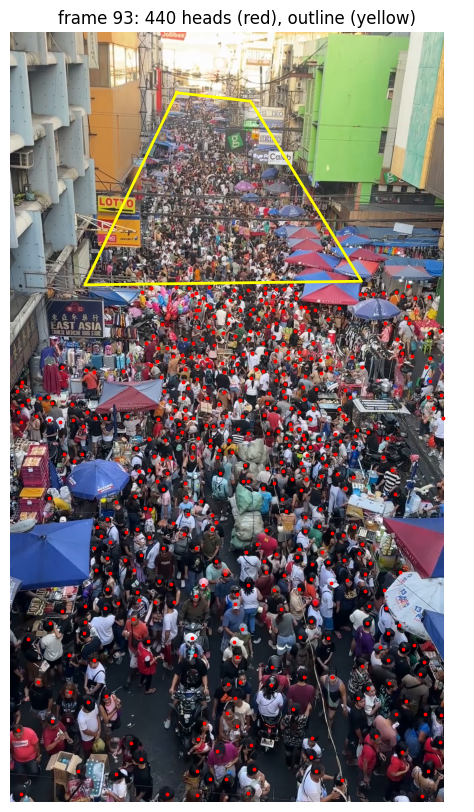

In [8]:
import matplotlib.pyplot as plt

def parse_via_v2(path):
    """Purpose: read a VIA JSON and return, per image, the head POINTS only (n = number of points)
    plus the polygon/rectangle outline(s) kept separately as `roi` (list of vertex lists).
    n_all is the old count of every region, kept for comparison."""
    data = json.loads(Path(path).read_text())
    meta = data.get("_via_img_metadata", data)
    rows = []
    for key, item in meta.items():
        if not isinstance(item, dict) or "regions" not in item:
            continue
        regs = item["regions"]
        regs = list(regs.values()) if isinstance(regs, dict) else regs
        pts, roi = [], []
        for r in regs:
            s = r.get("shape_attributes", {})
            if s.get("name") == "point":
                pts.append((s["cx"], s["cy"]))
            elif s.get("name") == "polygon":
                roi.append(list(zip(s["all_points_x"], s["all_points_y"])))
            elif s.get("name") == "rect":
                x, y, w, h = s["x"], s["y"], s["width"], s["height"]
                roi.append([(x, y), (x + w, y), (x + w, y + h), (x, y + h)])
        rows.append(dict(filename=item.get("filename", key), n=len(pts), n_all=len(regs), n_roi=len(roi), pts=pts, roi=roi))
    return pd.DataFrame(rows)

v2 = parse_via_v2(label_path).sort_values("filename").reset_index(drop=True)
v2 = v2[v2["n"] > 0].reset_index(drop=True)
old = labels.drop(columns=[c for c in ["n", "pts", "shapes"] if c in labels.columns])
labels = old.merge(v2, on="filename", how="inner")
print(labels[["filename", "frame", "n_all", "n", "n_roi"]].to_string(index=False))
print("\nheads (points only):", int(labels["n"].sum()), "| mean per frame", round(labels["n"].mean(), 1),
      "| outlines per frame:", sorted(set(labels["n_roi"])))
labels.to_pickle(OUT7 / "labelled_frames.pkl")
labels.drop(columns=["pts", "roi"]).to_csv(OUT7 / "labelled_frames.csv", index=False)

# look at one frame: points (red) and outline (yellow)
row = labels[labels["frame"] == 93].iloc[0] if (labels["frame"] == 93).any() else labels.iloc[0]
im = cv2.cvtColor(read_frames(VIDEO, idxs=[int(row["frame"])])[int(row["frame"])], cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(im)
ax.scatter([p[0] for p in row["pts"]], [p[1] for p in row["pts"]], s=3, c="red")
for poly in row["roi"]:
    xs, ys = zip(*(poly + [poly[0]]))
    ax.plot(xs, ys, c="yellow", lw=2)
ax.set_title(f"frame {int(row['frame'])}: {row['n']} heads (red), outline (yellow)"); ax.axis("off")
plt.show()

## Cell 4 – Load the three crowd counters and test them on one frame

We load three models: the official CSRNet trained on ShanghaiTech Part A, the official one trained on Part B, and our own Part B model from E004. Loading is strict, so any wrong layer name stops the cell. Then one labelled frame goes through our model. The density map should be 1/8 of the frame size (135×240 for a 1080×1920 frame), and its sum is the predicted head count.

In [9]:
import torch, torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)      # ImageNet statistics, as used in training
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def make_layers(cfg, in_ch=3, dilation=1):
    """Purpose: build a stack of 3x3 conv+ReLU layers from a list; 'M' means a 2x2 max-pool.
    `dilation` widens the receptive field without shrinking the map (used in the back end)."""
    layers = []
    for v in cfg:
        if v == "M":
            layers.append(nn.MaxPool2d(2, 2))
        else:
            layers += [nn.Conv2d(in_ch, v, 3, padding=dilation, dilation=dilation), nn.ReLU(inplace=True)]
            in_ch = v
    return nn.Sequential(*layers)

class CSRNet(nn.Module):
    """Purpose: CSRNet crowd counter. VGG16 front end (3 poolings, output = 1/8 size),
    6 dilated conv back end, 1x1 conv that outputs the density map. Layer names match
    the official checkpoints so weights load with strict=True."""
    def __init__(self):
        super().__init__()
        self.frontend = make_layers([64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512])
        self.backend = make_layers([512, 512, 512, 256, 128, 64], in_ch=512, dilation=2)
        self.output_layer = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        return self.output_layer(self.backend(self.frontend(x)))

def load_official(model, path):
    """Purpose: load an official CSRNet checkpoint (.pth.tar); strict, so any name/shape mismatch fails loudly."""
    ckpt = torch.load(path, map_location="cpu", weights_only=False)      # trusted file we uploaded ourselves
    sd = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
    model.load_state_dict({k.replace("module.", "", 1): v for k, v in sd.items()}, strict=True)
    return model

def load_ours(model, path):
    """Purpose: load our own E004 weights (a plain state_dict saved by Notebook 06)."""
    model.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    return model

def to_tensor(frame_bgr, scale=1.0):
    """Purpose: turn one BGR video frame into a normalised 1x3xHxW tensor. The frame is resized by
    `scale`, then to a multiple of 8 (the network works in steps of 8 pixels)."""
    h, w = frame_bgr.shape[:2]
    nh, nw = max(8, int(round(h * scale / 8)) * 8), max(8, int(round(w * scale / 8)) * 8)
    img = cv2.resize(frame_bgr, (nw, nh), interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR)
    rgb = (cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0 - MEAN) / STD
    return torch.from_numpy(rgb.transpose(2, 0, 1)).unsqueeze(0)

@torch.no_grad()
def predict_density(net, frame_bgr, scale=1.0):
    """Purpose: run one frame through `net`; returns the density map (numpy, H/8 x W/8 at that scale).
    Its sum is the predicted head count."""
    net.eval()
    return net(to_tensor(frame_bgr, scale).to(DEVICE)).squeeze().float().cpu().numpy()

def build_models():
    """Purpose: load the three candidate models: official Part A, official Part B, our Part B (E004)."""
    models = {}
    for name, path, loader in [("official_A", W_A, load_official), ("official_B", W_B, load_official), ("ours_B", W_OURS, load_ours)]:
        if path is None:            # a model whose weights are not attached is skipped
            continue
        net = CSRNet().to(DEVICE)
        models[name] = loader(net, path).eval()
    return models

n_params = sum(p.numel() for p in CSRNet().parameters())
assert n_params == 16_263_489, n_params
models = build_models()
print("parameters:", f"{n_params:,}", "| models loaded (strict):", list(models))

# quick sanity check: one labelled frame must give a map 1/8 of the size
lab = pd.read_pickle(OUT7 / "labelled_frames.pkl")
frames = read_frames(VIDEO, idxs=lab["frame"].tolist())
first = frames[int(lab["frame"].iloc[0])]
d = predict_density(next(iter(models.values())), first, 1.0)
print("frame", first.shape[:2], "-> density map", d.shape, "| predicted count (whole frame)", round(float(d.sum()), 1),
      "| hand count (labelled area only)", int(lab["n"].iloc[0]))

parameters: 16,263,489 | models loaded (strict): ['official_A', 'official_B', 'ours_B']


reading video:   0%|          | 0/1303 [00:00<?, ?it/s]

frame (1920, 1080) -> density map (240, 135) | predicted count (whole frame) 923.2 | hand count (labelled area only) 535


## Cell 5 – Which model and image size counts your video best?

You labelled heads everywhere except the far top part (the yellow outline), where heads are too tiny. So the fair test counts the model's prediction outside that outline (pred_labelled) and compares it with your hand count. We also print the whole-frame count (pred_all) just to see how much crowd lies in the far zone.

MAE: average miss in people. bias: average signed miss (negative = undercounting). ratio: predicted ÷ true (below 1 = undercounting).
LOO_MAE_after_scale: error after a one-number correction, where each frame is corrected by a factor learned only from the other 14.

With 15 frames, "best" is a rough guide, not a proof.

In [10]:
from tqdm.auto import tqdm

SCALES = (0.5, 0.75, 1.0)

def outline_mask(dens_shape, roi, frame_shape):
    """Purpose: mask (1 inside the hand-drawn outline(s), 0 elsewhere) at density-map size.
    Outline points are in full-frame pixels, so they are scaled down to the density map."""
    h, w = dens_shape
    fh, fw = frame_shape[:2]
    m = np.zeros((h, w), np.uint8)
    for poly in roi:
        p = np.array([[x * w / fw, y * h / fh] for x, y in poly], np.float32)
        cv2.fillPoly(m, [np.round(p).astype(np.int32)], 1)
    return m.astype(np.float32)

def count_table(models, frames, lab, scales=SCALES):
    """Purpose: predicted count of every model x scale x labelled frame: whole frame (pred_all),
    and only OUTSIDE the unlabelled far-zone outline (pred_labelled, the fair one to compare
    with the hand count), plus the count inside the outline (pred_far)."""
    rows = []
    for name, net in tqdm(models.items(), desc="models"):
        for sc in scales:
            for r in lab.itertuples():
                fr = frames[int(r.frame)]
                d = predict_density(net, fr, sc)
                far = outline_mask(d.shape, r.roi, fr.shape) if len(r.roi) else np.zeros_like(d)
                rows.append(dict(model=name, scale=sc, frame=int(r.frame), gt=int(r.n),
                                 pred_all=float(d.sum()), pred_labelled=float((d * (1 - far)).sum()),
                                 pred_far=float((d * far).sum())))
    return pd.DataFrame(rows)

def summarise(df, col):
    """Purpose: per model x scale: MAE, bias, mean pred/gt ratio and its spread across frames, for prediction column `col`."""
    d = df.assign(err=df[col] - df["gt"], ratio=df[col] / df["gt"])
    g = d.groupby(["model", "scale"])
    return pd.DataFrame(dict(MAE=g["err"].apply(lambda x: x.abs().mean()), bias=g["err"].mean(),
                             ratio_mean=g["ratio"].mean(), ratio_std=g["ratio"].std())).round(3).reset_index()

def loo_scaled_mae(df, col):
    """Purpose: honest 'after one-number correction' error: each frame is corrected by k = median(gt/pred)
    learned only from the OTHER frames."""
    out = []
    for (m, sc), g in df.groupby(["model", "scale"]):
        g = g.reset_index(drop=True)
        errs = [abs(g.loc[i, col] * np.median((g["gt"] / g[col]).drop(index=i)) - g.loc[i, "gt"]) for i in range(len(g))]
        out.append(dict(model=m, scale=sc, LOO_MAE_after_scale=float(np.mean(errs))))
    return pd.DataFrame(out).round(2)

lab = pd.read_pickle(OUT7 / "labelled_frames.pkl")
res = count_table(models, frames, lab)
res.to_csv(OUT7 / "labelled_predictions.csv", index=False)
summ = summarise(res, "pred_labelled").merge(loo_scaled_mae(res, "pred_labelled"), on=["model", "scale"])
summ["far_zone_count"] = res.groupby(["model", "scale"])["pred_far"].mean().round(1).values
summ.to_csv(OUT7 / "labelled_summary.csv", index=False)
print("=== fair comparison: model count OUTSIDE the far outline vs your hand count ===\n", summ.to_string(index=False))
b = summ.sort_values("MAE").iloc[0]
print(f"\nlowest raw MAE: {b['model']} @ scale {b['scale']} (MAE {b['MAE']:.1f}, bias {b['bias']:+.1f}, ratio {b['ratio_mean']:.2f})")
print(f"hand counts on {len(lab)} frames: mean {lab['n'].mean():.0f}, min {lab['n'].min()}, max {lab['n'].max()}")
print("far_zone_count = people the model sees INSIDE the outline (never hand-labelled). Only 15 frames: a rough guide.")

models:   0%|          | 0/3 [00:00<?, ?it/s]

=== fair comparison: model count OUTSIDE the far outline vs your hand count ===
      model  scale    MAE    bias  ratio_mean  ratio_std  LOO_MAE_after_scale  far_zone_count
official_A   0.50 26.654  24.866       1.054      0.049                18.92           160.1
official_A   0.75 49.212  48.150       1.103      0.086                34.58           258.6
official_A   1.00 37.336  20.130       1.041      0.097                47.20           284.1
official_B   0.50 46.679 -46.679       0.897      0.050                24.58           185.4
official_B   0.75 33.075  -6.881       0.982      0.087                35.93           413.4
official_B   1.00 43.142  -5.550       0.984      0.116                46.42           548.8
    ours_B   0.50 35.839  35.839       1.079      0.048                17.33           121.4
    ours_B   0.75 91.824  91.824       1.201      0.056                15.78           206.2
    ours_B   1.00 94.505  94.505       1.206      0.082                26.88      

## Cell 6 – Does the model put people in the right places?

A total count can be right for the wrong reasons: too many people in one part and too few in another. Pressure depends on where people are, so we also check space. We cut each frame into a 6×3 grid (6 rows from far to near, 3 columns), count your hand-labelled heads in each grid square, and compare with the model's count in the same square. The far outline is excluded. For each model and scale we print:

rel_err: total absolute miss per square, divided by the total hand count (lower is better)
r: how well the squares' counts follow each other (1.0 = perfect pattern)
ratio by row: predicted ÷ true from the far rows to the near rows. If it slopes, the model is biased with distance (perspective).

In [11]:
ROWS, COLS, MIN_GT = 6, 3, 10          # grid size; ignore squares with fewer hand-labelled heads than MIN_GT

def cell_edges(n, parts):
    """Purpose: integer boundaries that split `n` pixels (or map cells) into `parts` almost-equal strips."""
    return np.round(np.linspace(0, n, parts + 1)).astype(int)

def grid_counts_gt(pts, frame_hw):
    """Purpose: hand-labelled heads per grid square (ROWS x COLS) from the VIA points (x, y in frame pixels)."""
    h, w = frame_hw
    c = np.zeros((ROWS, COLS))
    for x, y in pts:
        r = min(int(y / h * ROWS), ROWS - 1); k = min(int(x / w * COLS), COLS - 1)
        c[r, k] += 1
    return c

def grid_counts_pred(dens, mask_far):
    """Purpose: model count per grid square: sum of the density map (outside the far outline) inside each square."""
    d = dens * (1 - mask_far)
    re, ce = cell_edges(d.shape[0], ROWS), cell_edges(d.shape[1], COLS)
    return np.array([[d[re[i]:re[i + 1], ce[j]:ce[j + 1]].sum() for j in range(COLS)] for i in range(ROWS)])

def spatial_table(models, frames, lab, combos):
    """Purpose: for each (model, scale) in `combos`, compare per-square counts with the hand counts on every labelled frame."""
    rows = []
    for name, sc in tqdm(combos, desc="spatial"):
        net = models[name]
        for r in lab.itertuples():
            fr = frames[int(r.frame)]
            d = predict_density(net, fr, sc)
            far = outline_mask(d.shape, r.roi, fr.shape) if len(r.roi) else np.zeros_like(d)
            g, p = grid_counts_gt(r.pts, fr.shape[:2]), grid_counts_pred(d, far)
            for i in range(ROWS):
                for j in range(COLS):
                    rows.append(dict(model=name, scale=sc, frame=int(r.frame), row=i, col=j, gt=g[i, j], pred=p[i, j]))
    return pd.DataFrame(rows)

def spatial_summary(sp):
    """Purpose: per model x scale: rel_err, Pearson r over all squares, and the pred/gt ratio for each grid row."""
    out = []
    for (m, sc), g in sp.groupby(["model", "scale"]):
        g = g[g["gt"] >= MIN_GT]
        rel = (g["pred"] - g["gt"]).abs().sum() / g["gt"].sum()
        rr = g.groupby("row").apply(lambda x: x["pred"].sum() / x["gt"].sum())
        out.append(dict(model=m, scale=sc, rel_err=round(rel, 3), r=round(np.corrcoef(g["gt"], g["pred"])[0, 1], 3),
                        **{f"row{k}": round(float(v), 2) for k, v in rr.items()}))
    return pd.DataFrame(out)

combos = [(m, s) for m in models for s in (0.5, 0.75)]        # scale 1.0 dropped: highest frame-to-frame wobble in Cell 5
sp = spatial_table(models, frames, lab, combos)
sp.to_csv(OUT7 / "spatial_cells.csv", index=False)
sp_sum = spatial_summary(sp)
sp_sum.to_csv(OUT7 / "spatial_summary.csv", index=False)
print(f"grid {ROWS}x{COLS}, squares with >= {MIN_GT} hand-labelled heads; row0 = far ... row{ROWS-1} = near")
print(sp_sum.to_string(index=False))
print("\nhand-labelled heads per row (all frames):", sp.groupby("row")["gt"].sum().astype(int).to_dict())

spatial:   0%|          | 0/6 [00:00<?, ?it/s]

grid 6x3, squares with >= 10 hand-labelled heads; row0 = far ... row5 = near
     model  scale  rel_err     r  row1  row2  row3  row4  row5
official_A   0.50    0.172 0.950  1.26  1.11  1.12  0.95  0.83
official_A   0.75    0.226 0.939  1.85  1.32  1.13  0.88  0.76
official_B   0.50    0.215 0.932  1.35  1.00  0.93  0.81  0.59
official_B   0.75    0.238 0.907  1.92  1.20  0.99  0.79  0.60
    ours_B   0.50    0.240 0.926  1.03  1.04  1.22  1.08  0.62
    ours_B   0.75    0.317 0.943  1.71  1.35  1.35  0.93  0.63

hand-labelled heads per row (all frames): {0: 0, 1: 732, 2: 11472, 3: 15216, 4: 8532, 5: 5016}


/tmp/ipykernel_59/613994483.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rr = g.groupby("row").apply(lambda x: x["pred"].sum() / x["gt"].sum())
/tmp/ipykernel_59/613994483.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rr = g.groupby("row").apply(lambda x: x["pred"].sum() / x["gt"].sum())
/tmp/ipykernel_59/613994483.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This beha

## Cell 7 – Count the whole video

Now we run the chosen models on all 1303 frames: official_A at 0.5 (best), our own ours_B at 0.5, and official_A at 0.75 (to see how sensitive the counts are to image size). Frames are read one at a time so memory stays small. For every frame and every model we save the total count and the count in each of the 6×3 grid squares (so any region can be summed later), and we save the density maps as compact files. At the end, a check makes sure that the labelled frames give the same numbers as in Cell 5.

counting video:   0%|          | 0/1303 [00:00<?, ?it/s]

frames processed: 1303
check vs Cell 5 (official_A@0.5, labelled frames): max difference 0.0000 heads

whole-frame count per combination (mean, min, max):
       official_A@0.5  ours_B@0.5  official_A@0.75
mean           638.0       616.0            758.0
min            554.0       558.0            652.0
max            734.0       713.0            883.0

correlation over time between combinations:
                  official_A@0.5  ours_B@0.5  official_A@0.75
official_A@0.5            1.000       0.862            0.740
ours_B@0.5                0.862       1.000            0.594
official_A@0.75           0.740       0.594            1.000


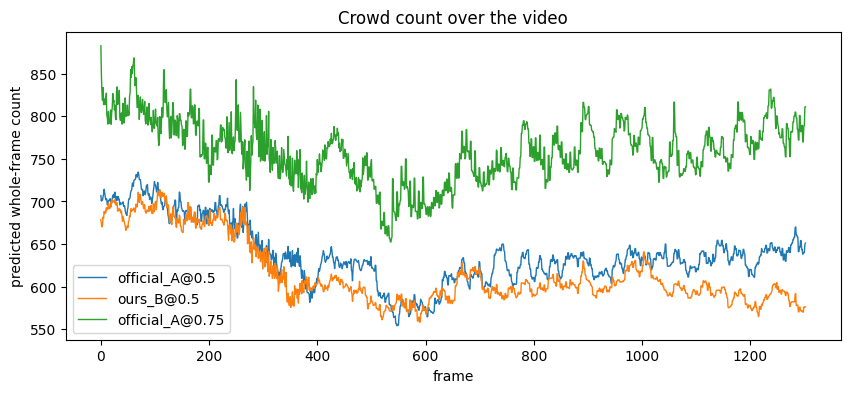

In [12]:
RUN = [("official_A", 0.5), ("ours_B", 0.5), ("official_A", 0.75)]     # chosen from Cells 5 and 6

def run_video(models, video, combos):
    """Purpose: read the video once, frame by frame, and for every (model, scale) in `combos` keep
    the total count, the 6x3 grid counts and the density map of every frame. Frames are not
    stored (1303 full frames would need ~8 GB), only the small results."""
    cap = cv2.VideoCapture(str(video))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    tot = {c: [] for c in combos}; grid = {c: [] for c in combos}; maps = {c: [] for c in combos}
    for i in tqdm(range(total), desc="counting video"):
        ok, fr = cap.read()
        if not ok:
            break
        for c in combos:
            d = predict_density(models[c[0]], fr, c[1])
            tot[c].append(float(d.sum()))
            grid[c].append(grid_counts_pred(d, np.zeros_like(d)))
            maps[c].append(d.astype(np.float16))            # half precision: 2 bytes per cell, enough for counts
    cap.release()
    return tot, grid, maps

tot, grid, maps = run_video(models, VIDEO, RUN)
n_frames = len(tot[RUN[0]])
print("frames processed:", n_frames)

# ---- save ----
df = pd.DataFrame({"frame": np.arange(n_frames)})
for (m, s) in RUN:
    df[f"{m}@{s}"] = tot[(m, s)]
df.to_csv(OUT7 / "density_counts_all_frames.csv", index=False)
for (m, s) in RUN:
    tag = f"{m}_{s}".replace(".", "p")
    np.save(OUT7 / f"grid_counts_{tag}.npy", np.stack(grid[(m, s)]).astype(np.float32))    # frames x 6 x 3
    np.savez_compressed(OUT7 / f"density_maps_{tag}.npz", maps=np.stack(maps[(m, s)]))     # frames x H/8 x W/8

# ---- check 1: same numbers as Cell 5 on the labelled frames (whole-frame counts) ----
chk = res[(res["model"] == "official_A") & (res["scale"] == 0.5)].set_index("frame")["pred_all"]
diff = (df.set_index("frame").loc[chk.index, "official_A@0.5"] - chk).abs().max()
print(f"check vs Cell 5 (official_A@0.5, labelled frames): max difference {diff:.4f} heads")
assert diff < 1.0, "counts differ from Cell 5: something is inconsistent"

# ---- check 2: how much do the three combinations agree, and how does the count change over time? ----
vals = df.drop(columns="frame")
print("\nwhole-frame count per combination (mean, min, max):\n", vals.describe().loc[["mean", "min", "max"]].round(0).to_string())
print("\ncorrelation over time between combinations:\n", vals.corr().round(3).to_string())
fig, ax = plt.subplots(figsize=(10, 4))
for c in vals.columns:
    ax.plot(df["frame"], vals[c], label=c, lw=1)
ax.set_xlabel("frame"); ax.set_ylabel("predicted whole-frame count"); ax.legend(); ax.set_title("Crowd count over the video")
plt.show()

## Cell 8 – Make a video of the counting

This cell builds an MP4 from your video and the saved density maps. Each frame shows:

a heat map on the crowd (red = dense),
a 6×3 grid of boxes, each with the number of people the model counts inside it,
the total count and the frame time at the top,
a count-over-time graph at the bottom with a moving marker.

Nothing is retrained. Change VIS to see a different model, e.g. ("ours_B", 0.5). The video is written at half size (540×960) and every 2nd frame, so it plays in real time at 30 fps.

In [13]:
import subprocess
from IPython.display import FileLink

VIS = ("official_A", 0.5)          # which saved model/scale to show; must be one of RUN
STEP, OUT_FPS = 2, 30               # use every 2nd frame of the 60 fps video -> real-time speed at 30 fps
W_OUT, H_OUT, H_PLOT = 540, 960, 150        # video panel size in pixels, and height of the graph strip

def load_maps(vis):
    """Purpose: load the saved density maps (frames x H/8 x W/8) for one (model, scale)."""
    tag = f"{vis[0]}_{vis[1]}".replace(".", "p")
    return np.load(OUT7 / f"density_maps_{tag}.npz")["maps"].astype(np.float32)

def draw_curve(series, w, h, marker_x=None):
    """Purpose: draw the count-over-time curve as a small image (w x h) with an optional vertical marker."""
    img = np.full((h, w, 3), 25, np.uint8)
    lo, hi = float(series.min()), float(series.max())
    xs = np.linspace(8, w - 8, len(series)).astype(np.int32)
    ys = (h - 22 - (series - lo) / max(hi - lo, 1e-6) * (h - 40)).astype(np.int32)
    cv2.polylines(img, [np.stack([xs, ys], 1)], False, (80, 200, 255), 2, cv2.LINE_AA)
    cv2.putText(img, f"count over time  (min {lo:.0f}, max {hi:.0f})", (8, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1, cv2.LINE_AA)
    if marker_x is not None:
        cv2.line(img, (int(marker_x), 20), (int(marker_x), h - 4), (255, 255, 255), 1)
    return img

def render_frame(frame_bgr, dens, vmax, i, n_frames, curve_base, fps_src):
    """Purpose: build one output image: frame + heat map + 6x3 grid boxes with counts + total count + curve."""
    img = cv2.resize(frame_bgr, (W_OUT, H_OUT), interpolation=cv2.INTER_AREA)
    d = cv2.resize(dens, (W_OUT, H_OUT), interpolation=cv2.INTER_CUBIC)         # smooth heat map at video size
    a = np.clip(d / vmax, 0, 1)                                                  # 0..1 strength (fixed vmax = stable colours)
    heat = cv2.applyColorMap((a * 255).astype(np.uint8), cv2.COLORMAP_JET)
    alpha = (a * 0.65)[..., None]
    img = (img * (1 - alpha) + heat * alpha).astype(np.uint8)
    counts = grid_counts_pred(dens, np.zeros_like(dens))                         # people per grid box, from the density map
    for r in range(ROWS):
        for c in range(COLS):
            x0, x1 = c * W_OUT // COLS, (c + 1) * W_OUT // COLS
            y0, y1 = r * H_OUT // ROWS, (r + 1) * H_OUT // ROWS
            cv2.rectangle(img, (x0, y0), (x1 - 1, y1 - 1), (255, 255, 255), 1)
            cv2.putText(img, f"{counts[r, c]:.0f}", (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(img, f"{counts[r, c]:.0f}", (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1, cv2.LINE_AA)
    cv2.rectangle(img, (0, 0), (W_OUT, 34), (0, 0, 0), -1)
    cv2.putText(img, f"{VIS[0]} @{VIS[1]}   count {dens.sum():.0f}   t = {i / fps_src:.2f} s   frame {i}",
                (8, 23), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    curve = curve_base.copy()
    mx = 8 + (W_OUT - 16) * i / max(n_frames - 1, 1)
    cv2.line(curve, (int(mx), 20), (int(mx), H_PLOT - 4), (255, 255, 255), 1)
    return np.vstack([img, curve])

def make_video(video, vis, out_path):
    """Purpose: write the visualisation video for the chosen model: reads the source video once,
    sequentially, and pairs each used frame with its saved density map."""
    maps = load_maps(vis)
    series = maps.reshape(len(maps), -1).sum(1)
    vmax = float(np.percentile(maps, 99.5))                                       # one colour scale for the whole video
    curve_base = draw_curve(series, W_OUT, H_PLOT)
    cap = cv2.VideoCapture(str(video))
    fps_src = cap.get(cv2.CAP_PROP_FPS) or 60.0
    wr = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), OUT_FPS, (W_OUT, H_OUT + H_PLOT))
    for i in tqdm(range(len(maps)), desc="writing video"):
        ok, fr = cap.read()
        if not ok:
            break
        if i % STEP == 0:
            wr.write(render_frame(fr, maps[i], vmax, i, len(maps), curve_base, fps_src))
    cap.release(); wr.release()

raw = OUT7 / "counting_video_raw.mp4"
final = OUT7 / f"counting_video_{VIS[0]}_{VIS[1]}.mp4".replace(".mp4", "").replace("0.5", "0p5").replace("0.75", "0p75") if False else OUT7 / f"counting_video_{VIS[0]}_{str(VIS[1]).replace('.', 'p')}.mp4"
make_video(VIDEO, VIS, raw)
try:        # re-encode to H.264 so it plays in browsers and phones
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(raw), "-vcodec", "libx264", "-pix_fmt", "yuv420p", "-crf", "23", str(final)], check=True)
    raw.unlink()
except Exception as e:
    print("ffmpeg re-encode failed, keeping the raw file:", e); raw.rename(final)
print(f"video: {final}  ({final.stat().st_size/1e6:.1f} MB)")
final_link = FileLink(str(final).replace("/kaggle/working/", ""))
final_link

writing video:   0%|          | 0/1303 [00:00<?, ?it/s]

video: /kaggle/working/outputs/E005/counting_video_official_A_0p5.mp4  (15.8 MB)


/kaggle/working/outputs/E005/counting_video_official_A_0p5.mp4

## Cell 9 – Video with red dots on heads

For every frame, the model's density map is turned into dots: we find the strongest separate peaks of the density and mark them with red dots. Number of dots = the predicted count (or fewer if the map does not have that many separate peaks). The count and time are written at the top, and a small graph at the bottom shows the count over time.

First a single-frame check shows red dots (model) and green dots (your hand labels) together, so you can judge how well they agree. Only then is the video made. Uses the saved density maps, no model runs

reading video:   0%|          | 0/1303 [00:00<?, ?it/s]

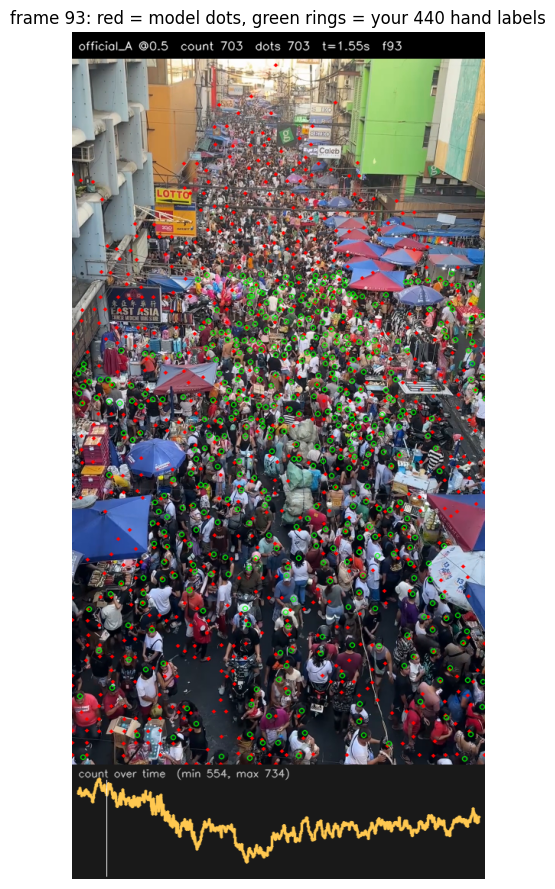

writing dots video:   0%|          | 0/1303 [00:00<?, ?it/s]

video: /kaggle/working/outputs/E005/dots_video_official_A_0p5.mp4  (18.5 MB)


/kaggle/working/outputs/E005/dots_video_official_A_0p5.mp4

In [14]:
DOT_WIN, DOT_R = 7, 2           # min spacing between dots (output pixels) and dot radius
SHOW_HEAT = False               # True = also draw the colour heat map under the dots

def pick_dots(d_up, k, win=DOT_WIN):
    """Purpose: choose up to k head positions from an upsampled density map: local maxima of the
    (lightly blurred) density, strongest first. Returns x and y pixel arrays."""
    d = cv2.GaussianBlur(d_up, (0, 0), 1.5)
    peak = (d >= cv2.dilate(d, np.ones((win, win), np.uint8))) & (d > 1e-6)
    ys, xs = np.nonzero(peak)
    order = np.argsort(-d[ys, xs])[:max(int(round(k)), 0)]
    return xs[order], ys[order]

def render_dots_frame(frame_bgr, dens, vmax, i, n_frames, curve_base, fps_src, gt_pts=None):
    """Purpose: one output image: frame + red dots at estimated heads (+ optional heat map and green
    hand-labelled points) + count/time text + count-over-time curve."""
    img = cv2.resize(frame_bgr, (W_OUT, H_OUT), interpolation=cv2.INTER_AREA)
    d = cv2.resize(dens, (W_OUT, H_OUT), interpolation=cv2.INTER_CUBIC)
    if SHOW_HEAT:
        a = np.clip(d / vmax, 0, 1)
        heat = cv2.applyColorMap((a * 255).astype(np.uint8), cv2.COLORMAP_JET)
        alpha = (a * 0.45)[..., None]
        img = (img * (1 - alpha) + heat * alpha).astype(np.uint8)
    xs, ys = pick_dots(d, dens.sum())
    for x, y in zip(xs, ys):
        cv2.circle(img, (int(x), int(y)), DOT_R, (0, 0, 255), -1, cv2.LINE_AA)          # red = model
    if gt_pts is not None:
        sx, sy = W_OUT / frame_bgr.shape[1], H_OUT / frame_bgr.shape[0]
        for x, y in gt_pts:
            cv2.circle(img, (int(x * sx), int(y * sy)), DOT_R + 1, (0, 255, 0), 1, cv2.LINE_AA)   # green ring = hand label
    cv2.rectangle(img, (0, 0), (W_OUT, 34), (0, 0, 0), -1)
    cv2.putText(img, f"{VIS[0]} @{VIS[1]}  count {dens.sum():.0f}  dots {len(xs)}  t={i / fps_src:.2f}s  f{i}",
                (8, 23), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    curve = curve_base.copy()
    mx = 8 + (W_OUT - 16) * i / max(n_frames - 1, 1)
    cv2.line(curve, (int(mx), 20), (int(mx), H_PLOT - 4), (255, 255, 255), 1)
    return np.vstack([img, curve])

# ---- 1) single-frame check against your hand labels ----
maps = load_maps(VIS)
vmax = float(np.percentile(maps, 99.5))
curve_base = draw_curve(maps.reshape(len(maps), -1).sum(1), W_OUT, H_PLOT)
row = lab[lab["frame"] == 93].iloc[0] if (lab["frame"] == 93).any() else lab.iloc[0]
fi = int(row["frame"])
fr = read_frames(VIDEO, idxs=[fi])[fi]
chk_img = render_dots_frame(fr, maps[fi], vmax, fi, len(maps), curve_base, 59.94, gt_pts=row["pts"])
fig, ax = plt.subplots(figsize=(6, 11)); ax.imshow(cv2.cvtColor(chk_img, cv2.COLOR_BGR2RGB)); ax.axis("off")
ax.set_title(f"frame {fi}: red = model dots, green rings = your {int(row['n'])} hand labels"); plt.show()

# ---- 2) the video ----
def make_dots_video(video, out_path):
    """Purpose: write the red-dot video for VIS: reads the source video once, sequentially, pairing every
    used frame with its saved density map."""
    cap = cv2.VideoCapture(str(video))
    fps_src = cap.get(cv2.CAP_PROP_FPS) or 60.0
    wr = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), OUT_FPS, (W_OUT, H_OUT + H_PLOT))
    for i in tqdm(range(len(maps)), desc="writing dots video"):
        ok, f = cap.read()
        if not ok:
            break
        if i % STEP == 0:
            wr.write(render_dots_frame(f, maps[i], vmax, i, len(maps), curve_base, fps_src))
    cap.release(); wr.release()

raw = OUT7 / "dots_video_raw.mp4"
final = OUT7 / f"dots_video_{VIS[0]}_{str(VIS[1]).replace('.', 'p')}.mp4"
make_dots_video(VIDEO, raw)
try:
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(raw), "-vcodec", "libx264", "-pix_fmt", "yuv420p", "-crf", "23", str(final)], check=True)
    raw.unlink()
except Exception as e:
    print("ffmpeg re-encode failed, keeping the raw file:", e); raw.rename(final)
print(f"video: {final}  ({final.stat().st_size/1e6:.1f} MB)")
FileLink(str(final).replace("/kaggle/working/", ""))

In [15]:
import re, subprocess
from scipy.io import loadmat
from IPython.display import FileLink

MALL_SCALE = 1.0          # Mall frames are small (~640x480) with small heads, so use full size
MALL_STEP, MALL_MAX = 2, 1000       # use every 2nd frame, at most 1000 frames
PANEL_W = 480
MALL_MODELS = ["official_A", "ours_B"]

def frame_number(path):
    """Purpose: last integer in a file name (seq_000123.jpg -> 123), to sort frames in true order."""
    nums = re.findall(r"\d+", Path(path).stem)
    return int(nums[-1]) if nums else -1

def find_frame_folder(root=INPUT, min_frames=500):
    """Purpose: the folder under `root` with the most image files (the frame sequence); returns (folder, ordered paths)."""
    groups = {}
    for p in Path(root).rglob("*"):
        if p.is_file() and p.suffix.lower() in (".jpg", ".jpeg", ".png"):
            groups.setdefault(p.parent, []).append(p)
    folder, files = max(groups.items(), key=lambda kv: len(kv[1]))
    if len(files) < min_frames:
        raise RuntimeError(f"largest image folder {folder} has only {len(files)} images; folders: { {str(k): len(v) for k, v in groups.items()} }")
    return folder, sorted(files, key=frame_number)

def load_mall_gt(root=INPUT):
    """Purpose: look for the Mall ground truth (a .mat with a 'count' array, or a .csv with a count column).
    Returns (counts array or None, description of what was found)."""
    for p in Path(root).rglob("*"):
        if not p.is_file():
            continue
        try:
            if p.suffix.lower() == ".mat":
                m = loadmat(str(p))
                if "count" in m:
                    return np.asarray(m["count"]).ravel().astype(float), f"{p.name}: 'count' with {np.asarray(m['count']).size} values"
            elif p.suffix.lower() == ".csv" and "gt" in p.name.lower():
                t = pd.read_csv(p)
                col = [c for c in t.columns if "count" in c.lower()]
                if col:
                    return t[col[0]].to_numpy(float), f"{p.name}: column '{col[0]}'"
        except Exception:
            continue
    return None, "no ground-truth file found (looked for a .mat with 'count' or a csv named *gt*)"

def load_mall_roi(root=INPUT):
    """Purpose: look for the Mall region-of-interest mask (perspective_roi.mat, field roi.mask).
    Returns (mask array or None, description). The official Mall counts cover only this region."""
    for p in Path(root).rglob("*roi*.mat"):
        try:
            m = loadmat(str(p), squeeze_me=True, struct_as_record=False)
            mask = np.asarray(m["roi"].mask).astype(np.float32)
            return mask, f"{p.name}: mask {mask.shape}, {mask.mean()*100:.0f}% of the frame"
        except Exception as e:
            return None, f"{p.name} found but could not be read ({e})"
    return None, "no ROI file found"

def mall_panel(frame_bgr, net, name, scale, roi, w=PANEL_W):
    """Purpose: one panel with red dots at estimated heads and a header; also returns the whole-frame count and
    the count inside the ROI (if a mask was found)."""
    dens = predict_density(net, frame_bgr, scale)
    h = int(round(frame_bgr.shape[0] * w / frame_bgr.shape[1] / 2) * 2)
    img = cv2.resize(frame_bgr, (w, h), interpolation=cv2.INTER_AREA)
    d = cv2.resize(dens, (w, h), interpolation=cv2.INTER_CUBIC)
    whole = float(dens.sum())
    in_roi = whole
    if roi is not None:
        m = cv2.resize(roi, (dens.shape[1], dens.shape[0]), interpolation=cv2.INTER_NEAREST)
        in_roi = float((dens * m).sum())
        d = d * cv2.resize(roi, (w, h), interpolation=cv2.INTER_NEAREST)
    xs, ys = pick_dots(d, in_roi, win=9)
    for x, y in zip(xs, ys):
        cv2.circle(img, (int(x), int(y)), 3, (0, 0, 255), -1, cv2.LINE_AA)
    cv2.rectangle(img, (0, 0), (w, 28), (0, 0, 0), -1)
    cv2.putText(img, f"{name}  count {in_roi:.1f}  dots {len(xs)}", (6, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return img, whole, in_roi

def run_mall(files, names, scale, step, max_frames, roi, gt, out_path, fps=10):
    """Purpose: go through the frame files, write a side-by-side red-dot video, save 4 stills, and return a per-frame
    table with whole-frame counts, ROI counts and (if known) the true count."""
    idx = list(range(0, min(len(files), max_frames * step), step))
    stills = {idx[int(len(idx) * f)] for f in (0.1, 0.35, 0.6, 0.85)}
    wr, rows = None, []
    for i in tqdm(idx, desc="Mall frames"):
        fr = cv2.imread(str(files[i]))
        outs = [mall_panel(fr, models[m], m, scale, roi) for m in names]
        img = np.hstack([o[0] for o in outs])
        if wr is None:
            wr = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (img.shape[1], img.shape[0]))
        wr.write(img)
        row = dict(frame=frame_number(files[i]), gt=(gt[i] if gt is not None and i < len(gt) else np.nan))
        for m, o in zip(names, outs):
            row[f"{m}_whole"], row[f"{m}_roi"] = o[1], o[2]
        rows.append(row)
        if i in stills:
            cv2.imwrite(str(OUT7 / f"mall_still_{frame_number(files[i]):05d}.jpg"), img)
    wr.release()
    return pd.DataFrame(rows)

folder, files = find_frame_folder()
gt, gt_msg = load_mall_gt()
roi, roi_msg = load_mall_roi()
print(f"frames: {folder} ({len(files)} images)\nground truth: {gt_msg}\nROI: {roi_msg}")
if gt is not None and len(gt) != len(files):
    print(f"WARNING: {len(gt)} ground-truth values but {len(files)} images; aligned by position, check this")

raw_m, final_m = OUT7 / "mall_dots_raw.mp4", OUT7 / "mall_dots_video.mp4"
mall = run_mall(files, MALL_MODELS, MALL_SCALE, MALL_STEP, MALL_MAX, roi, gt, raw_m)
mall.to_csv(OUT7 / "mall_counts.csv", index=False)
try:
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(raw_m), "-vcodec", "libx264", "-pix_fmt", "yuv420p", "-crf", "23", str(final_m)], check=True)
    raw_m.unlink()
except Exception as e:
    print("ffmpeg re-encode failed, keeping the raw file:", e); raw_m.rename(final_m)

if mall["gt"].notna().any():
    rows = []
    for m in MALL_MODELS:
        for kind in ("whole", "roi"):
            e = mall[f"{m}_{kind}"] - mall["gt"]
            rows.append(dict(model=m, counted="whole frame" if kind == "whole" else "inside ROI", MAE=e.abs().mean(),
                             bias=e.mean(), ratio=(mall[f"{m}_{kind}"] / mall["gt"]).mean()))
    print(f"\nscore on {len(mall)} frames (true count mean {mall['gt'].mean():.1f}, min {mall['gt'].min():.0f}, max {mall['gt'].max():.0f}):")
    print(pd.DataFrame(rows).round(2).to_string(index=False))
else:
    print("\nno ground truth: counts only:", mall.drop(columns="frame").describe().loc[["mean", "min", "max"]].round(1).to_string())
print("\nsaved:", final_m, "| stills:", sorted(p.name for p in OUT7.glob("mall_still_*.jpg")))
FileLink(str(final_m).replace("/kaggle/working/", ""))

frames: /kaggle/input/datasets/chaozhuang/mall-dataset/frames/frames (2000 images)
ground truth: mall_gt.mat: 'count' with 2000 values
ROI: perspective_roi.mat: mask (480, 640), 90% of the frame


Mall frames:   0%|          | 0/1000 [00:00<?, ?it/s]


score on 1000 frames (true count mean 31.2, min 14, max 50):
     model     counted   MAE   bias  ratio
official_A whole frame 11.99 -11.99   0.62
official_A  inside ROI 13.51 -13.51   0.57
    ours_B whole frame  3.92  -2.83   0.92
    ours_B  inside ROI  5.26  -4.99   0.85

saved: /kaggle/working/outputs/E005/mall_dots_video.mp4 | stills: ['mall_still_00201.jpg', 'mall_still_00701.jpg', 'mall_still_01201.jpg', 'mall_still_01701.jpg']


/kaggle/working/outputs/E005/mall_dots_video.mp4

## Cell 7b – Is the model's change over time real?

Two checks, no new model runs:

Does the model follow your hand counts from frame to frame? Among the 15 labelled frames we compare how the hand count and the model's count (outside the far outline) move together (Pearson and Spearman correlation, where 1.0 = they rise and fall together).
Are the fast wiggles real or noise? Real crowd changes are seen by every model, so the frame-to-frame changes of different models should correlate. If they don't, the wiggles are noise. We also print how large the frame-to-frame change is relative to the mean count, before and after smoothing over 15 frames (0.25 s).

In [16]:
from scipy.stats import spearmanr, pearsonr

def track_hand_counts(res, col="pred_labelled"):
    """Purpose: for each model x scale, how well the prediction follows the hand count across the
    labelled frames (Pearson and Spearman correlation)."""
    rows = []
    for (m, s), g in res.groupby(["model", "scale"]):
        rows.append(dict(model=m, scale=s, pearson=round(pearsonr(g["gt"], g[col])[0], 3),
                         spearman=round(spearmanr(g["gt"], g[col])[0], 3)))
    return pd.DataFrame(rows)

def wiggle_report(df, win=15):
    """Purpose: size of frame-to-frame changes (std of the first difference / mean count), the same after
    smoothing over `win` frames, and the correlation between different models' first differences."""
    v = df.drop(columns="frame")
    d1 = v.diff().dropna()
    sm = v.rolling(win, center=True).mean().dropna()
    out = pd.DataFrame(dict(mean=v.mean(), step_std=d1.std(), step_pct=(d1.std() / v.mean() * 100),
                            step_std_smooth=sm.diff().dropna().std(), slow_range=(sm.max() - sm.min()))).round(2)
    return out, d1.corr().round(3), sm.diff().dropna().corr().round(3)

print("=== 1) does the model follow the hand count over the 15 labelled frames? (pred_labelled vs gt) ===")
print(track_hand_counts(res).to_string(index=False))
print("\nhand counts vs frame:", dict(zip(lab["frame"], lab["n"])))

rep, corr_raw, corr_smooth = wiggle_report(df)
print("\n=== 2) frame-to-frame wiggle (whole-frame counts) ===\n", rep.to_string())
print("\ncorrelation of frame-to-frame CHANGES between combinations (raw):\n", corr_raw.to_string())
print("\ncorrelation of frame-to-frame changes after 15-frame smoothing:\n", corr_smooth.to_string())
print("\nReading guide: raw-change correlation near 0 = wiggles are model noise, not real people.")

=== 1) does the model follow the hand count over the 15 labelled frames? (pred_labelled vs gt) ===
     model  scale  pearson  spearman
official_A   0.50    0.868     0.793
official_A   0.75    0.845     0.754
official_A   1.00    0.839     0.789
official_B   0.50    0.855     0.761
official_B   0.75    0.808     0.700
official_B   1.00    0.756     0.571
    ours_B   0.50    0.846     0.664
    ours_B   0.75    0.872     0.754
    ours_B   1.00    0.823     0.643

hand counts vs frame: {0: 535, 93: 440, 186: 503, 279: 454, 372: 438, 465: 401, 558: 488, 651: 447, 744: 413, 837: 449, 930: 441, 1023: 452, 1116: 434, 1209: 473, 1302: 460}

=== 2) frame-to-frame wiggle (whole-frame counts) ===
                    mean  step_std  step_pct  step_std_smooth  slow_range
official_A@0.5   637.89      5.66      0.89             1.10      164.47
ours_B@0.5       615.72      5.67      0.92             0.89      139.93
official_A@0.75  758.43     14.42      1.90             1.98      180.81

correla

## Cell 7c – Is the 'follows the hand count' result real or just frame 0?

With only 15 labelled frames, one frame can hold a correlation up. Here we drop frame 0, and then each frame in turn, and print the lowest and highest Pearson correlation each model still gets. If the range stays high, the result does not depend on any single frame.

In [17]:
def loo_pearson(res, col="pred_labelled"):
    """Purpose: per model x scale, Pearson r (prediction vs hand count) on all frames, without frame 0,
    and the min/max of r when each single frame is left out in turn."""
    rows = []
    for (m, s), g in res.groupby(["model", "scale"]):
        g = g.reset_index(drop=True)
        r_all = np.corrcoef(g["gt"], g[col])[0, 1]
        g0 = g[g["frame"] != 0]
        r_no0 = np.corrcoef(g0["gt"], g0[col])[0, 1]
        loo = [np.corrcoef(g.drop(index=i)["gt"], g.drop(index=i)[col])[0, 1] for i in range(len(g))]
        rows.append(dict(model=m, scale=s, r_all=round(r_all, 3), r_without_frame0=round(r_no0, 3),
                         r_leave1_min=round(min(loo), 3), r_leave1_max=round(max(loo), 3)))
    return pd.DataFrame(rows)

print(loo_pearson(res).to_string(index=False))

     model  scale  r_all  r_without_frame0  r_leave1_min  r_leave1_max
official_A   0.50  0.868             0.762         0.762         0.900
official_A   0.75  0.845             0.710         0.710         0.898
official_A   1.00  0.839             0.697         0.697         0.911
official_B   0.50  0.855             0.735         0.735         0.878
official_B   0.75  0.808             0.650         0.650         0.867
official_B   1.00  0.756             0.526         0.526         0.839
    ours_B   0.50  0.846             0.715         0.715         0.890
    ours_B   0.75  0.872             0.770         0.770         0.907
    ours_B   1.00  0.823             0.663         0.663         0.868


## cell 11 – Pack the E005 results for GitHub

Copies the small result files (tables, pictures, stills) into results_E005, writes a summary.json with the key numbers, and zips it for download. Large files (density maps, videos, grid arrays) stay in the Kaggle Output tab and are only listed, because they are too heavy for the repo. Put the downloaded folder into results/E005 in your local repo.

In [18]:
import shutil, json

def pack_e005(src, dst, max_mb=5.0):
    """Purpose: copy files under `src` smaller than `max_mb` into `dst`; return (copied names, skipped big files)."""
    dst = Path(dst)
    if dst.exists():
        shutil.rmtree(dst)
    dst.mkdir(parents=True)
    copied, skipped = [], []
    for p in sorted(Path(src).iterdir()):
        if not p.is_file():
            continue
        if p.stat().st_size / 1e6 <= max_mb:
            shutil.copy2(p, dst / p.name); copied.append(p.name)
        else:
            skipped.append(f"{p.name} ({p.stat().st_size/1e6:.0f} MB)")
    return copied, skipped

track = track_hand_counts(res)
summary = dict(
    experiment="E005", video_frames=int(n_frames), labelled_frames=int(len(lab)), hand_heads_total=int(lab["n"].sum()),
    street_15_frames=summ.round(3).to_dict(orient="records"),
    spatial_6x3=sp_sum.to_dict(orient="records"),
    tracking_hand_counts=track.to_dict(orient="records"),
    wiggle=rep.to_dict(orient="index"),
    mall=dict(frames=int(len(mall)), true_mean=float(mall["gt"].mean())) if "mall" in globals() else None,
    note="far-zone outline in labels = unlabelled area; scores use the area outside it; 15 frames only",
)
if "mall" in globals() and mall["gt"].notna().any():
    summary["mall"]["scores"] = {f"{m}_{k}": dict(MAE=float((mall[f'{m}_{k}'] - mall['gt']).abs().mean()),
                                                   bias=float((mall[f'{m}_{k}'] - mall['gt']).mean()))
                                 for m in MALL_MODELS for k in ("whole", "roi")}
(OUT7 / "summary.json").write_text(json.dumps(summary, indent=2, default=float))

dst = Path("/kaggle/working/results_E005")
copied, skipped = pack_e005(OUT7, dst)
print("copied:", copied, "\nleft in the Output tab (too big for git):", skipped)
zip_path = shutil.make_archive("/kaggle/working/results_E005", "zip", dst)
print("zip:", zip_path, f"({Path(zip_path).stat().st_size/1e6:.1f} MB)")
FileLink("results_E005.zip")

copied: ['density_counts_all_frames.csv', 'grid_counts_official_A_0p5.npy', 'grid_counts_official_A_0p75.npy', 'grid_counts_ours_B_0p5.npy', 'labelled_frames.csv', 'labelled_frames.pkl', 'labelled_predictions.csv', 'labelled_summary.csv', 'mall_counts.csv', 'mall_still_00201.jpg', 'mall_still_00701.jpg', 'mall_still_01201.jpg', 'mall_still_01701.jpg', 'spatial_cells.csv', 'spatial_summary.csv', 'summary.json'] 
left in the Output tab (too big for git): ['counting_video_official_A_0p5.mp4 (16 MB)', 'density_maps_official_A_0p5.npz (20 MB)', 'density_maps_official_A_0p75.npz (44 MB)', 'density_maps_ours_B_0p5.npz (19 MB)', 'dots_video_official_A_0p5.mp4 (19 MB)', 'mall_dots_video.mp4 (17 MB)', 'video_thumbs.npy (37 MB)']
zip: /kaggle/working/results_E005.zip (0.9 MB)


/kaggle/working/results_E005.zip